<a href="https://www.kaggle.com/code/lalit7881/student-placement-career-success-2026-eda?scriptVersionId=322667377" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")
import plotly.express as px
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shambhurajejagadale/student-placement-and-career-success-dataset-2026/student_placement_career_success_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shambhurajejagadale/student-placement-and-career-success-dataset-2026/student_placement_career_success_dataset.csv")

In [3]:
df.head()

,student_id,age,gender,state,city_tier,college_tier,branch,degree,cgpa,backlog_history,...,work_mode,salary_lpa,interview_rounds_cleared,offer_count,joining_delay_months,layoffs_risk_score,AI_tool_usage_frequency,prompt_engineering_skill,AI_fear_score,adaptability_score
0,STU00001,22,Male,Karnataka,1,2,Computer Science,MCA,6.71,3,...,Remote,17.36,4,1,2,62,55,55,19,81
1,STU00002,20,Male,Tamil Nadu,2,3,AI & DS,BTech,6.14,0,...,Onsite,18.22,3,3,0,55,66,52,54,76
2,STU00003,23,Female,Uttar Pradesh,3,2,Computer Science,BTech,7.11,0,...,Remote,22.08,1,3,1,79,69,67,49,34
3,STU00004,25,Male,Maharashtra,2,3,Civil,BTech,7.41,0,...,Remote,20.87,2,1,2,44,44,65,61,46
4,STU00005,25,Female,West Bengal,3,3,Civil,BE,8.29,0,...,Onsite,20.57,5,3,5,23,57,67,71,44


In [4]:
df.tail()

,student_id,age,gender,state,city_tier,college_tier,branch,degree,cgpa,backlog_history,...,work_mode,salary_lpa,interview_rounds_cleared,offer_count,joining_delay_months,layoffs_risk_score,AI_tool_usage_frequency,prompt_engineering_skill,AI_fear_score,adaptability_score
24995,STU24996,23,Female,Telangana,2,1,Computer Science,MCA,8.42,0,...,Hybrid,26.74,2,2,3,26,55,53,26,53
24996,STU24997,20,Female,Tamil Nadu,2,2,Civil,BTech,7.45,1,...,Remote,16.07,1,3,2,27,44,53,81,47
24997,STU24998,24,Male,Karnataka,2,3,Mechanical,MCA,7.34,0,...,Hybrid,20.22,4,1,4,17,43,72,24,87
24998,STU24999,20,Male,Delhi,2,2,Information Technology,BTech,7.59,1,...,Hybrid,19.79,2,2,3,49,93,53,59,77
24999,STU25000,23,Female,Maharashtra,1,2,Civil,BTech,7.67,0,...,Onsite,16.84,4,1,4,27,81,57,63,55


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 44 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  25000 non-null  object 
 1   age                         25000 non-null  int64  
 2   gender                      25000 non-null  object 
 3   state                       25000 non-null  object 
 4   city_tier                   25000 non-null  int64  
 5   college_tier                25000 non-null  int64  
 6   branch                      25000 non-null  object 
 7   degree                      25000 non-null  object 
 8   cgpa                        25000 non-null  float64
 9   backlog_history             25000 non-null  int64  
 10  attendance_percentage       25000 non-null  float64
 11  primary_language            25000 non-null  object 
 12  DSA_problems_solved         25000 non-null  int64  
 13  GitHub_repos                245

In [6]:
df.describe()

,age,city_tier,college_tier,cgpa,backlog_history,attendance_percentage,DSA_problems_solved,GitHub_repos,hackathons_participated,development_projects_count,...,motivation_level,salary_lpa,interview_rounds_cleared,offer_count,joining_delay_months,layoffs_risk_score,AI_tool_usage_frequency,prompt_engineering_skill,AI_fear_score,adaptability_score
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,24500.000000,25000.000000,25000.000000,...,25000.0000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,22.507520,2.104360,2.354160,7.460975,0.468040,77.942360,646.777800,18.688490,2.612720,6.396520,...,69.3320,19.006936,2.972560,1.967400,2.45592,34.786640,59.333080,60.375200,44.549720,64.460400
std,1.706898,0.768201,0.726217,0.846094,0.810262,9.956108,124.989386,9.219579,1.835709,2.631921,...,14.7297,4.244388,1.445811,0.845107,1.71551,15.110894,19.396358,16.647395,19.782843,14.944899
min,20.000000,1.000000,1.000000,5.000000,0.000000,45.000000,185.000000,0.000000,0.000000,1.000000,...,5.0000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,21.000000,2.000000,2.000000,6.890000,0.000000,71.200000,562.000000,12.000000,1.000000,5.000000,...,59.0000,16.750000,2.000000,1.000000,1.00000,24.000000,46.000000,49.000000,31.000000,54.000000
50%,22.000000,2.000000,3.000000,7.460000,0.000000,78.000000,646.000000,18.000000,3.000000,6.000000,...,70.0000,19.130000,3.000000,2.000000,2.00000,35.000000,60.000000,60.000000,45.000000,64.000000
75%,24.000000,3.000000,3.000000,8.030000,1.000000,84.900000,731.000000,25.000000,4.000000,8.000000,...,80.0000,21.570000,4.000000,3.000000,4.00000,45.000000,73.000000,72.000000,58.000000,75.000000
max,25.000000,3.000000,3.000000,10.000000,3.000000,100.000000,1163.000000,60.000000,10.000000,18.000000,...,100.0000,35.100000,5.000000,3.000000,5.00000,100.000000,100.000000,100.000000,100.000000,100.000000


In [7]:
df.isnull()

,student_id,age,gender,state,city_tier,college_tier,branch,degree,cgpa,backlog_history,...,work_mode,salary_lpa,interview_rounds_cleared,offer_count,joining_delay_months,layoffs_risk_score,AI_tool_usage_frequency,prompt_engineering_skill,AI_fear_score,adaptability_score
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
24996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
24997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
24998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

student_id                      0
age                             0
gender                          0
state                           0
city_tier                       0
college_tier                    0
branch                          0
degree                          0
cgpa                            0
backlog_history                 0
attendance_percentage           0
primary_language                0
DSA_problems_solved             0
GitHub_repos                  500
hackathons_participated         0
development_projects_count      0
AI_ML_projects                  0
internships_completed           0
resume_score                    0
communication_skills            0
aptitude_score                  0
mock_interview_score          500
sleep_hours                   500
screen_time                     0
gaming_hours                    0
study_hours_daily               0
stress_level                    0
burnout_score                   0
gym_frequency                   0
family_income_

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['student_id', 'age', 'gender', 'state', 'city_tier', 'college_tier',
       'branch', 'degree', 'cgpa', 'backlog_history', 'attendance_percentage',
       'primary_language', 'DSA_problems_solved', 'GitHub_repos',
       'hackathons_participated', 'development_projects_count',
       'AI_ML_projects', 'internships_completed', 'resume_score',
       'communication_skills', 'aptitude_score', 'mock_interview_score',
       'sleep_hours', 'screen_time', 'gaming_hours', 'study_hours_daily',
       'stress_level', 'burnout_score', 'gym_frequency', 'family_income_lpa',
       'self_learning_hours', 'motivation_level', 'placement_status',
       'company_type', 'work_mode', 'salary_lpa', 'interview_rounds_cleared',
       'offer_count', 'joining_delay_months', 'layoffs_risk_score',
       'AI_tool_usage_frequency', 'prompt_engineering_skill', 'AI_fear_score',
       'adaptability_score'],
      dtype='object')

In [11]:
df.dtypes

student_id                     object
age                             int64
gender                         object
state                          object
city_tier                       int64
college_tier                    int64
branch                         object
degree                         object
cgpa                          float64
backlog_history                 int64
attendance_percentage         float64
primary_language               object
DSA_problems_solved             int64
GitHub_repos                  float64
hackathons_participated         int64
development_projects_count      int64
AI_ML_projects                  int64
internships_completed           int64
resume_score                    int64
communication_skills            int64
aptitude_score                  int64
mock_interview_score          float64
sleep_hours                   float64
screen_time                   float64
gaming_hours                  float64
study_hours_daily             float64
stress_level

In [12]:
df.shape

(25000, 44)

In [13]:
df.nunique()

student_id                    25000
age                               6
gender                            3
state                             8
city_tier                         3
college_tier                      3
branch                            6
degree                            3
cgpa                            497
backlog_history                   4
attendance_percentage           532
primary_language                  6
DSA_problems_solved             777
GitHub_repos                     58
hackathons_participated          11
development_projects_count       18
AI_ML_projects                   12
internships_completed            12
resume_score                     75
communication_skills             61
aptitude_score                   75
mock_interview_score             75
sleep_hours                      71
screen_time                     125
gaming_hours                     91
study_hours_daily               101
stress_level                    101
burnout_score               

## EDA

In [14]:
# =========================
# STYLE SETTINGS
# =========================
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12,6)

# =========================
# COLOR PALETTES
# =========================
colors1 = ["#FF5733", "#33FF57", "#3357FF", "#FF33A8", "#FFC300"]
colors2 = ["#6A0572", "#AB83A1", "#F67280", "#C06C84", "#355C7D"]
colors3 = ["#00B8A9", "#F6416C", "#FFDE7D", "#6A2C70", "#2E86AB"]


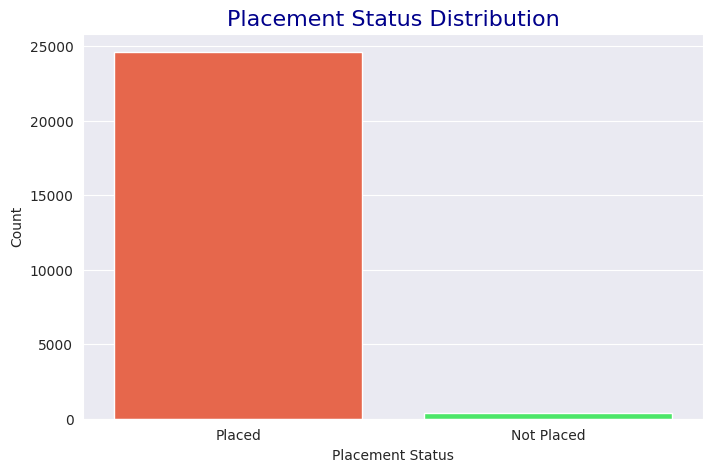

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='placement_status',
    data=df,
    palette=colors1
)

plt.title("Placement Status Distribution", fontsize=16, color='darkblue')
plt.xlabel("Placement Status")
plt.ylabel("Count")
plt.show()

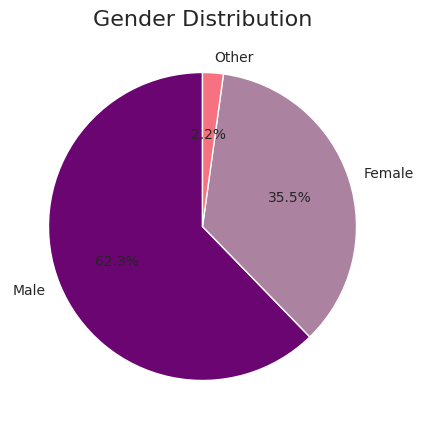

In [16]:
plt.figure(figsize=(7,5))
df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors2,
    startangle=90
)

plt.title("Gender Distribution", fontsize=16)
plt.ylabel("")
plt.show()


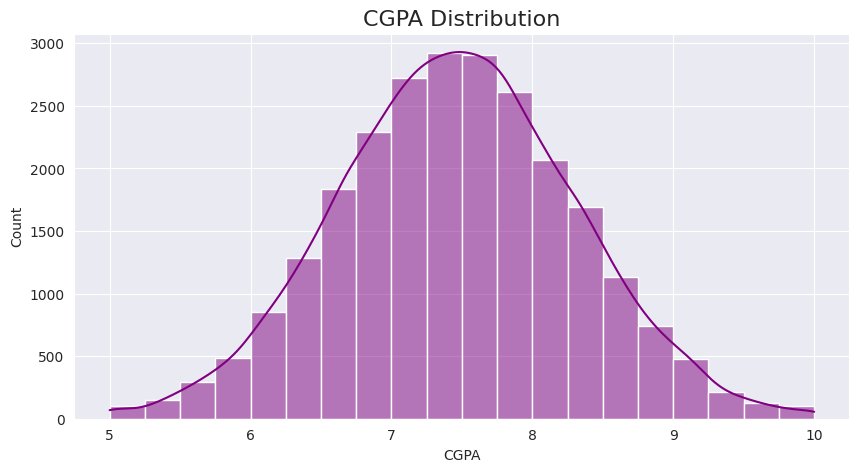

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(
    df['cgpa'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title("CGPA Distribution", fontsize=16)
plt.xlabel("CGPA")
plt.show()

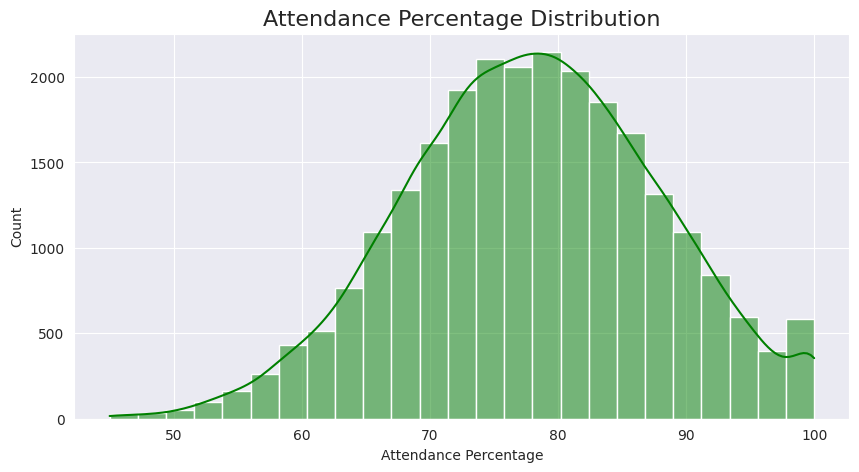

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(
    df['attendance_percentage'],
    bins=25,
    kde=True,
    color='green'
)

plt.title("Attendance Percentage Distribution", fontsize=16)
plt.xlabel("Attendance Percentage")
plt.show()

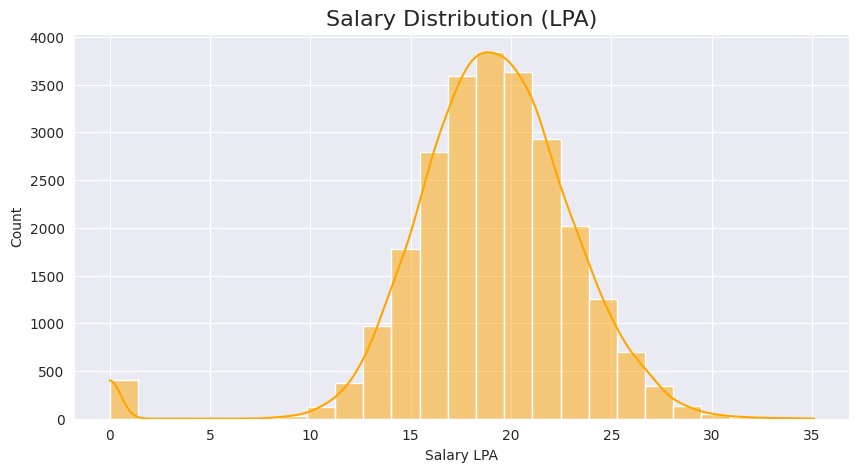

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(
    df['salary_lpa'],
    bins=25,
    kde=True,
    color='orange'
)

plt.title("Salary Distribution (LPA)", fontsize=16)
plt.xlabel("Salary LPA")
plt.show()

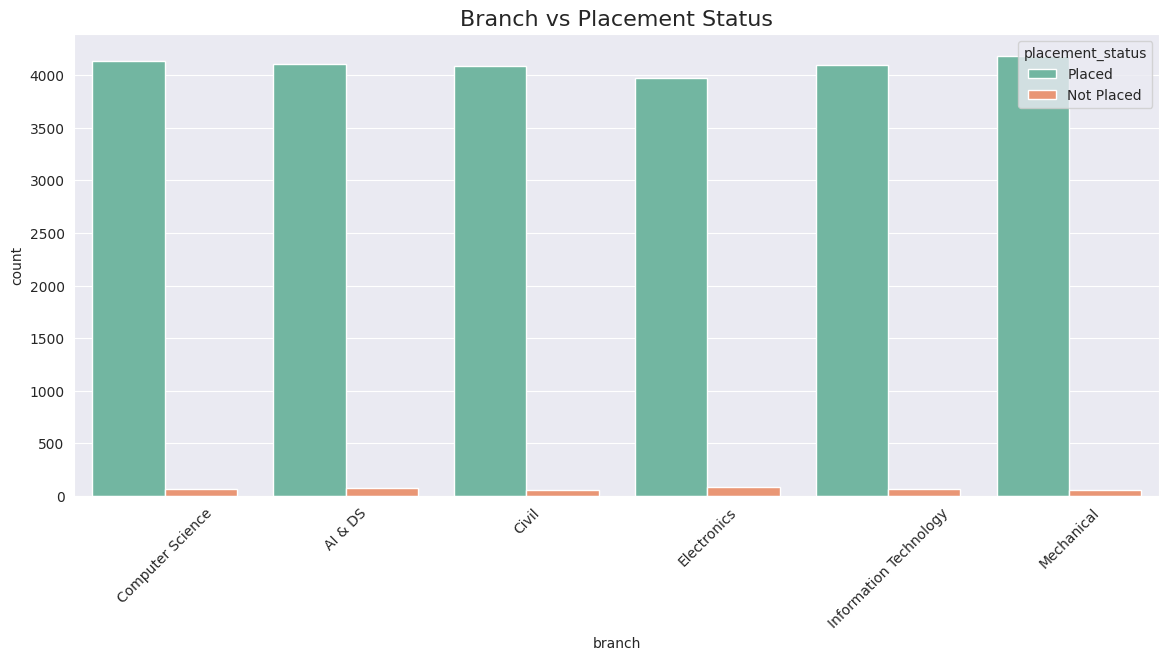

In [20]:
plt.figure(figsize=(14,6))
sns.countplot(
    x='branch',
    hue='placement_status',
    data=df,
    palette='Set2'
)

plt.title("Branch vs Placement Status", fontsize=16)
plt.xticks(rotation=45)
plt.show()

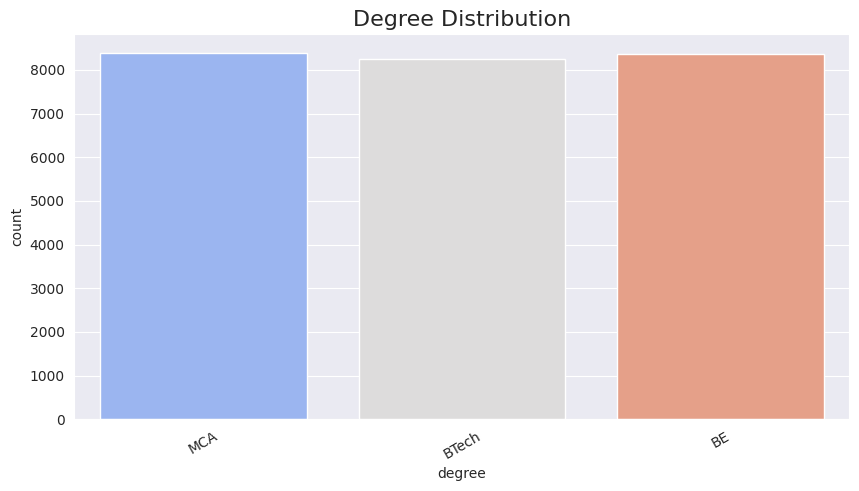

In [21]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='degree',
    data=df,
    palette='coolwarm'
)

plt.title("Degree Distribution", fontsize=16)
plt.xticks(rotation=30)
plt.show()

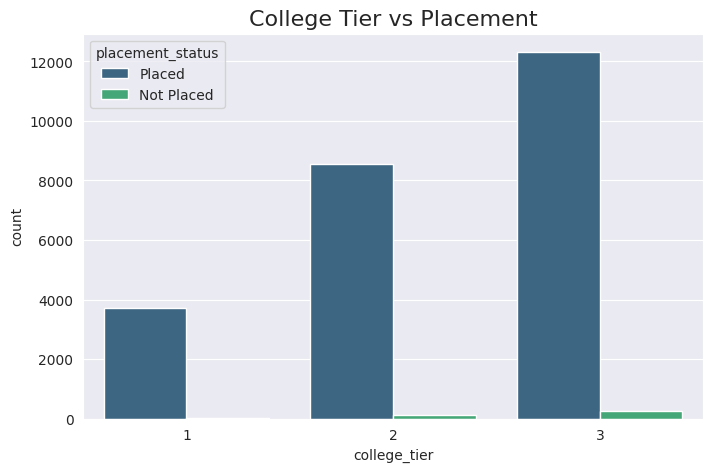

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(
    x='college_tier',
    hue='placement_status',
    data=df,
    palette='viridis'
)

plt.title("College Tier vs Placement", fontsize=16)
plt.show()

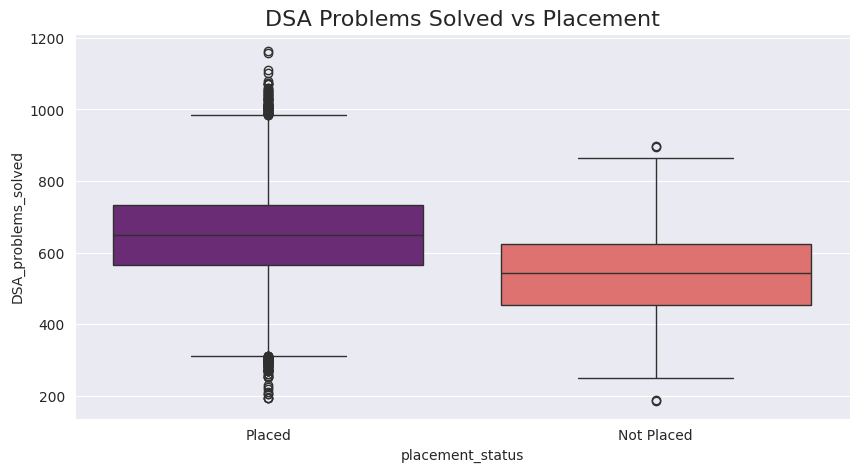

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='placement_status',
    y='DSA_problems_solved',
    data=df,
    palette='magma'
)

plt.title("DSA Problems Solved vs Placement", fontsize=16)
plt.show()

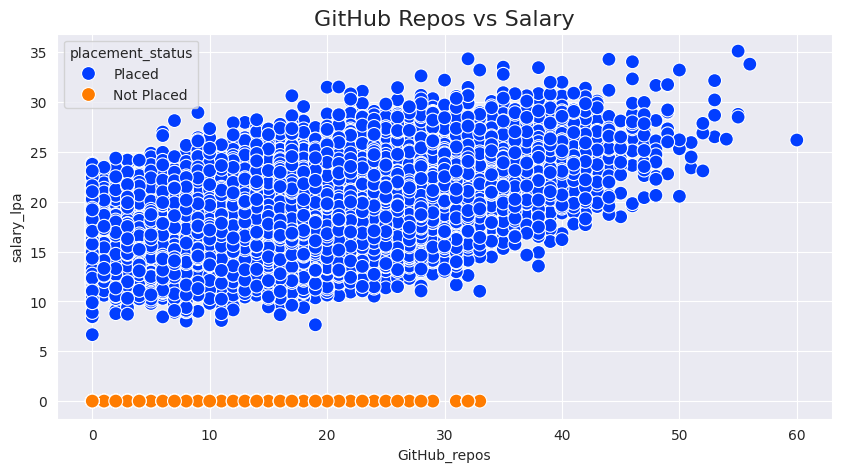

In [24]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='GitHub_repos',
    y='salary_lpa',
    hue='placement_status',
    data=df,
    palette='bright',
    s=100
)

plt.title("GitHub Repos vs Salary", fontsize=16)
plt.show()

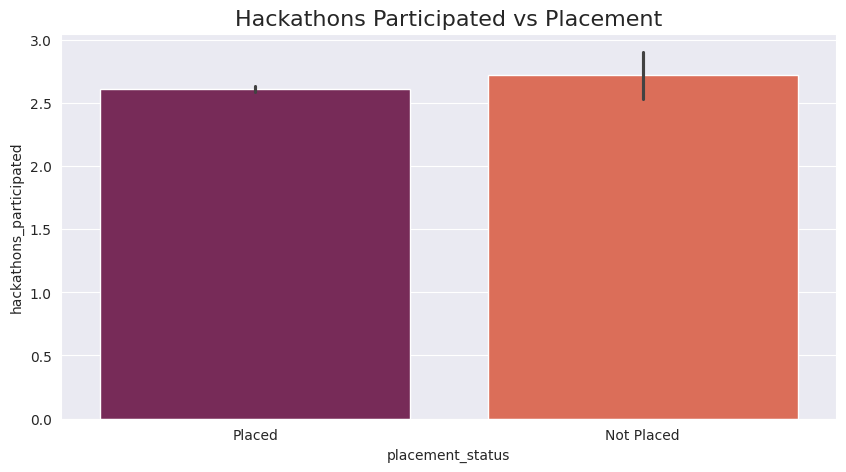

In [25]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='placement_status',
    y='hackathons_participated',
    data=df,
    palette='rocket'
)

plt.title("Hackathons Participated vs Placement", fontsize=16)
plt.show()

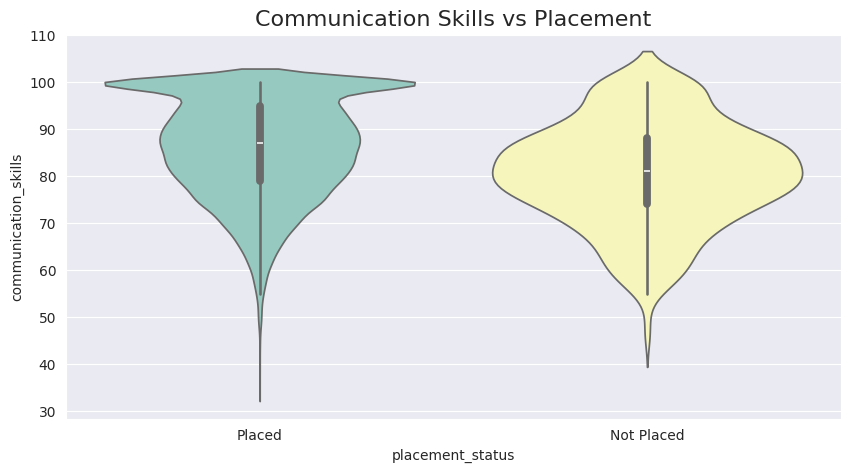

In [26]:
plt.figure(figsize=(10,5))
sns.violinplot(
    x='placement_status',
    y='communication_skills',
    data=df,
    palette='Set3'
)

plt.title("Communication Skills vs Placement", fontsize=16)
plt.show()

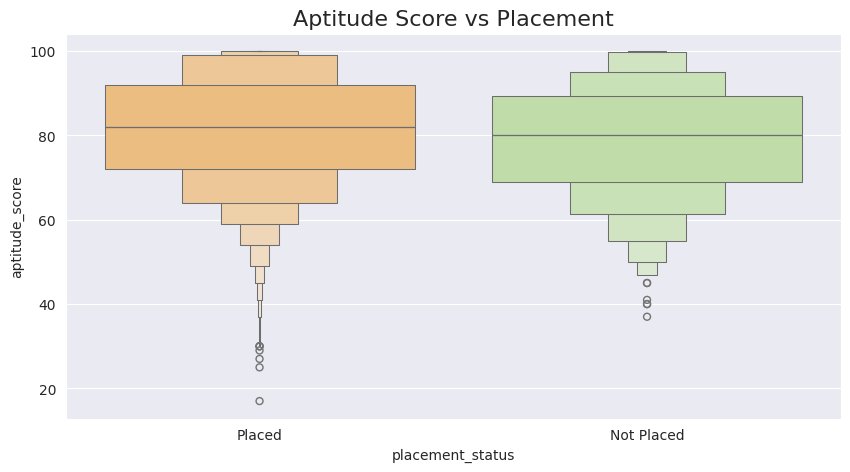

In [27]:
plt.figure(figsize=(10,5))
sns.boxenplot(
    x='placement_status',
    y='aptitude_score',
    data=df,
    palette='Spectral'
)

plt.title("Aptitude Score vs Placement", fontsize=16)
plt.show()

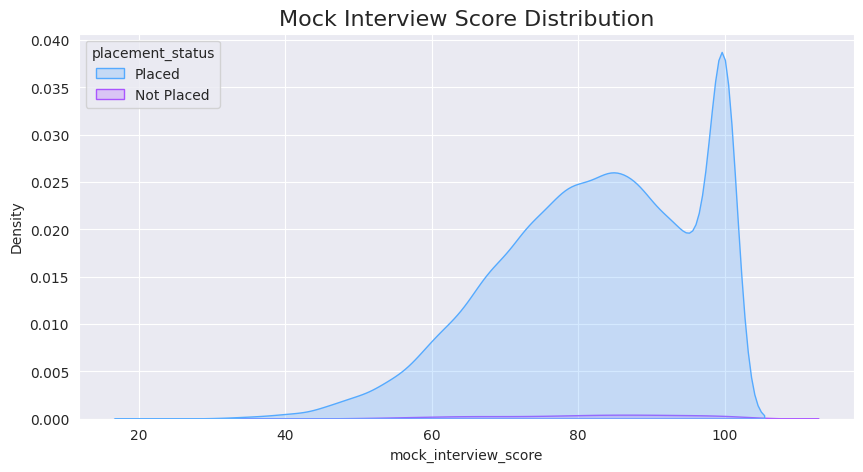

In [28]:
plt.figure(figsize=(10,5))
sns.kdeplot(
    data=df,
    x='mock_interview_score',
    hue='placement_status',
    fill=True,
    palette='cool'
)

plt.title("Mock Interview Score Distribution", fontsize=16)
plt.show()

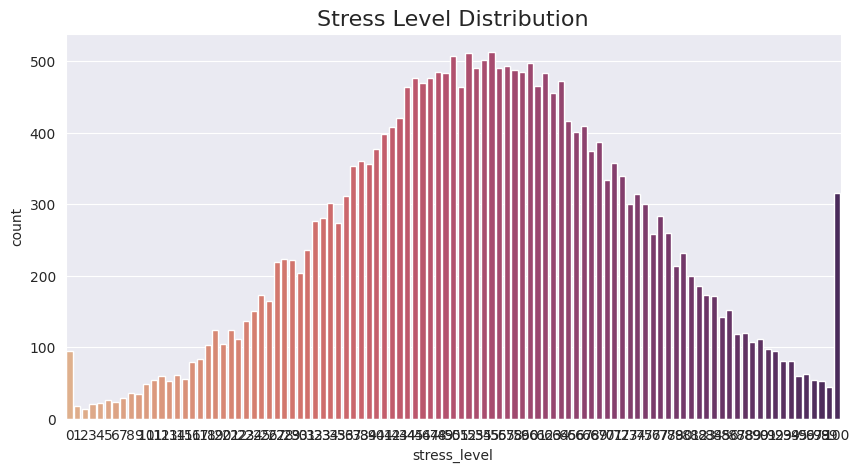

In [29]:
plt.figure(figsize=(10,5))
sns.countplot(
    x='stress_level',
    data=df,
    palette='flare'
)

plt.title("Stress Level Distribution", fontsize=16)
plt.show()

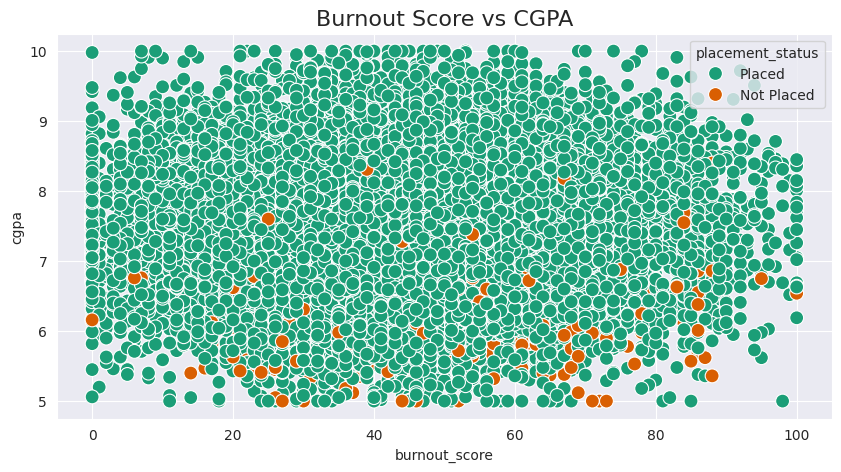

In [30]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='burnout_score',
    y='cgpa',
    hue='placement_status',
    palette='Dark2',
    data=df,
    s=100
)

plt.title("Burnout Score vs CGPA", fontsize=16)
plt.show()

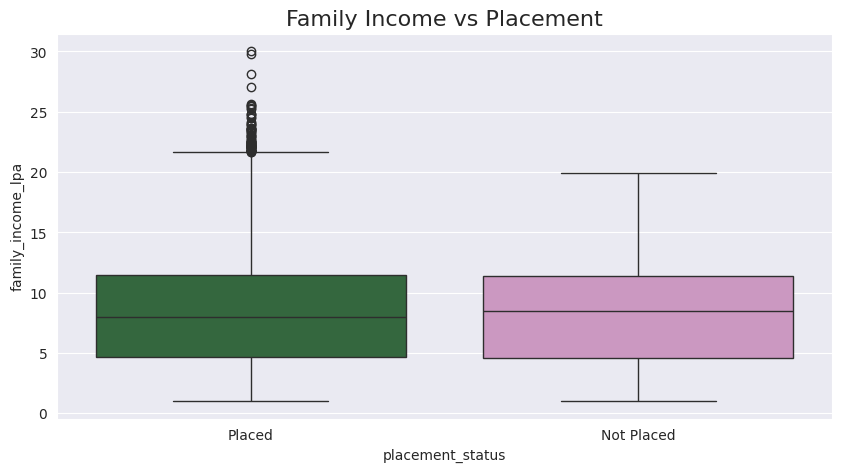

In [31]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='placement_status',
    y='family_income_lpa',
    data=df,
    palette='cubehelix'
)

plt.title("Family Income vs Placement", fontsize=16)
plt.show()

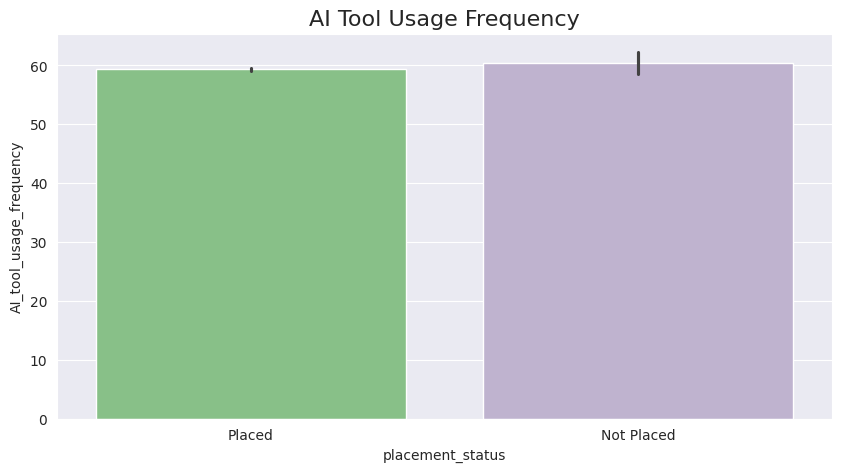

In [32]:
plt.figure(figsize=(10,5))
sns.barplot(
    x='placement_status',
    y='AI_tool_usage_frequency',
    data=df,
    palette='Accent'
)

plt.title("AI Tool Usage Frequency", fontsize=16)
plt.show()

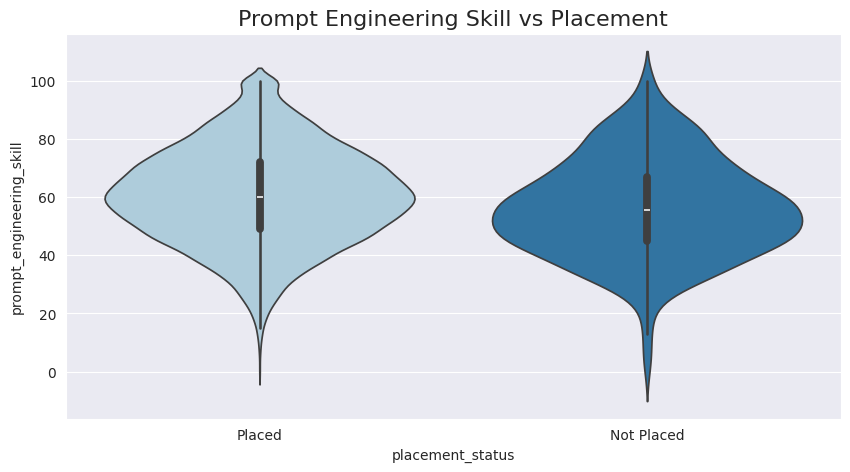

In [33]:
plt.figure(figsize=(10,5))
sns.violinplot(
    x='placement_status',
    y='prompt_engineering_skill',
    data=df,
    palette='Paired'
)

plt.title("Prompt Engineering Skill vs Placement", fontsize=16)
plt.show()

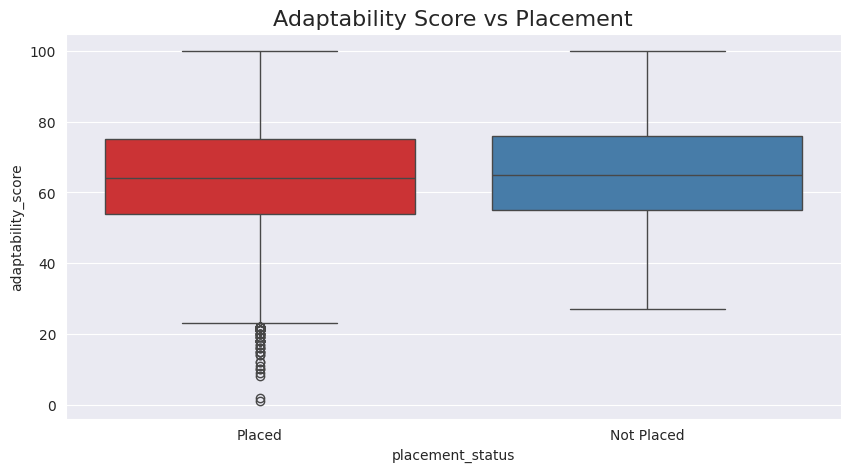

In [34]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='placement_status',
    y='adaptability_score',
    data=df,
    palette='Set1'
)

plt.title("Adaptability Score vs Placement", fontsize=16)
plt.show()

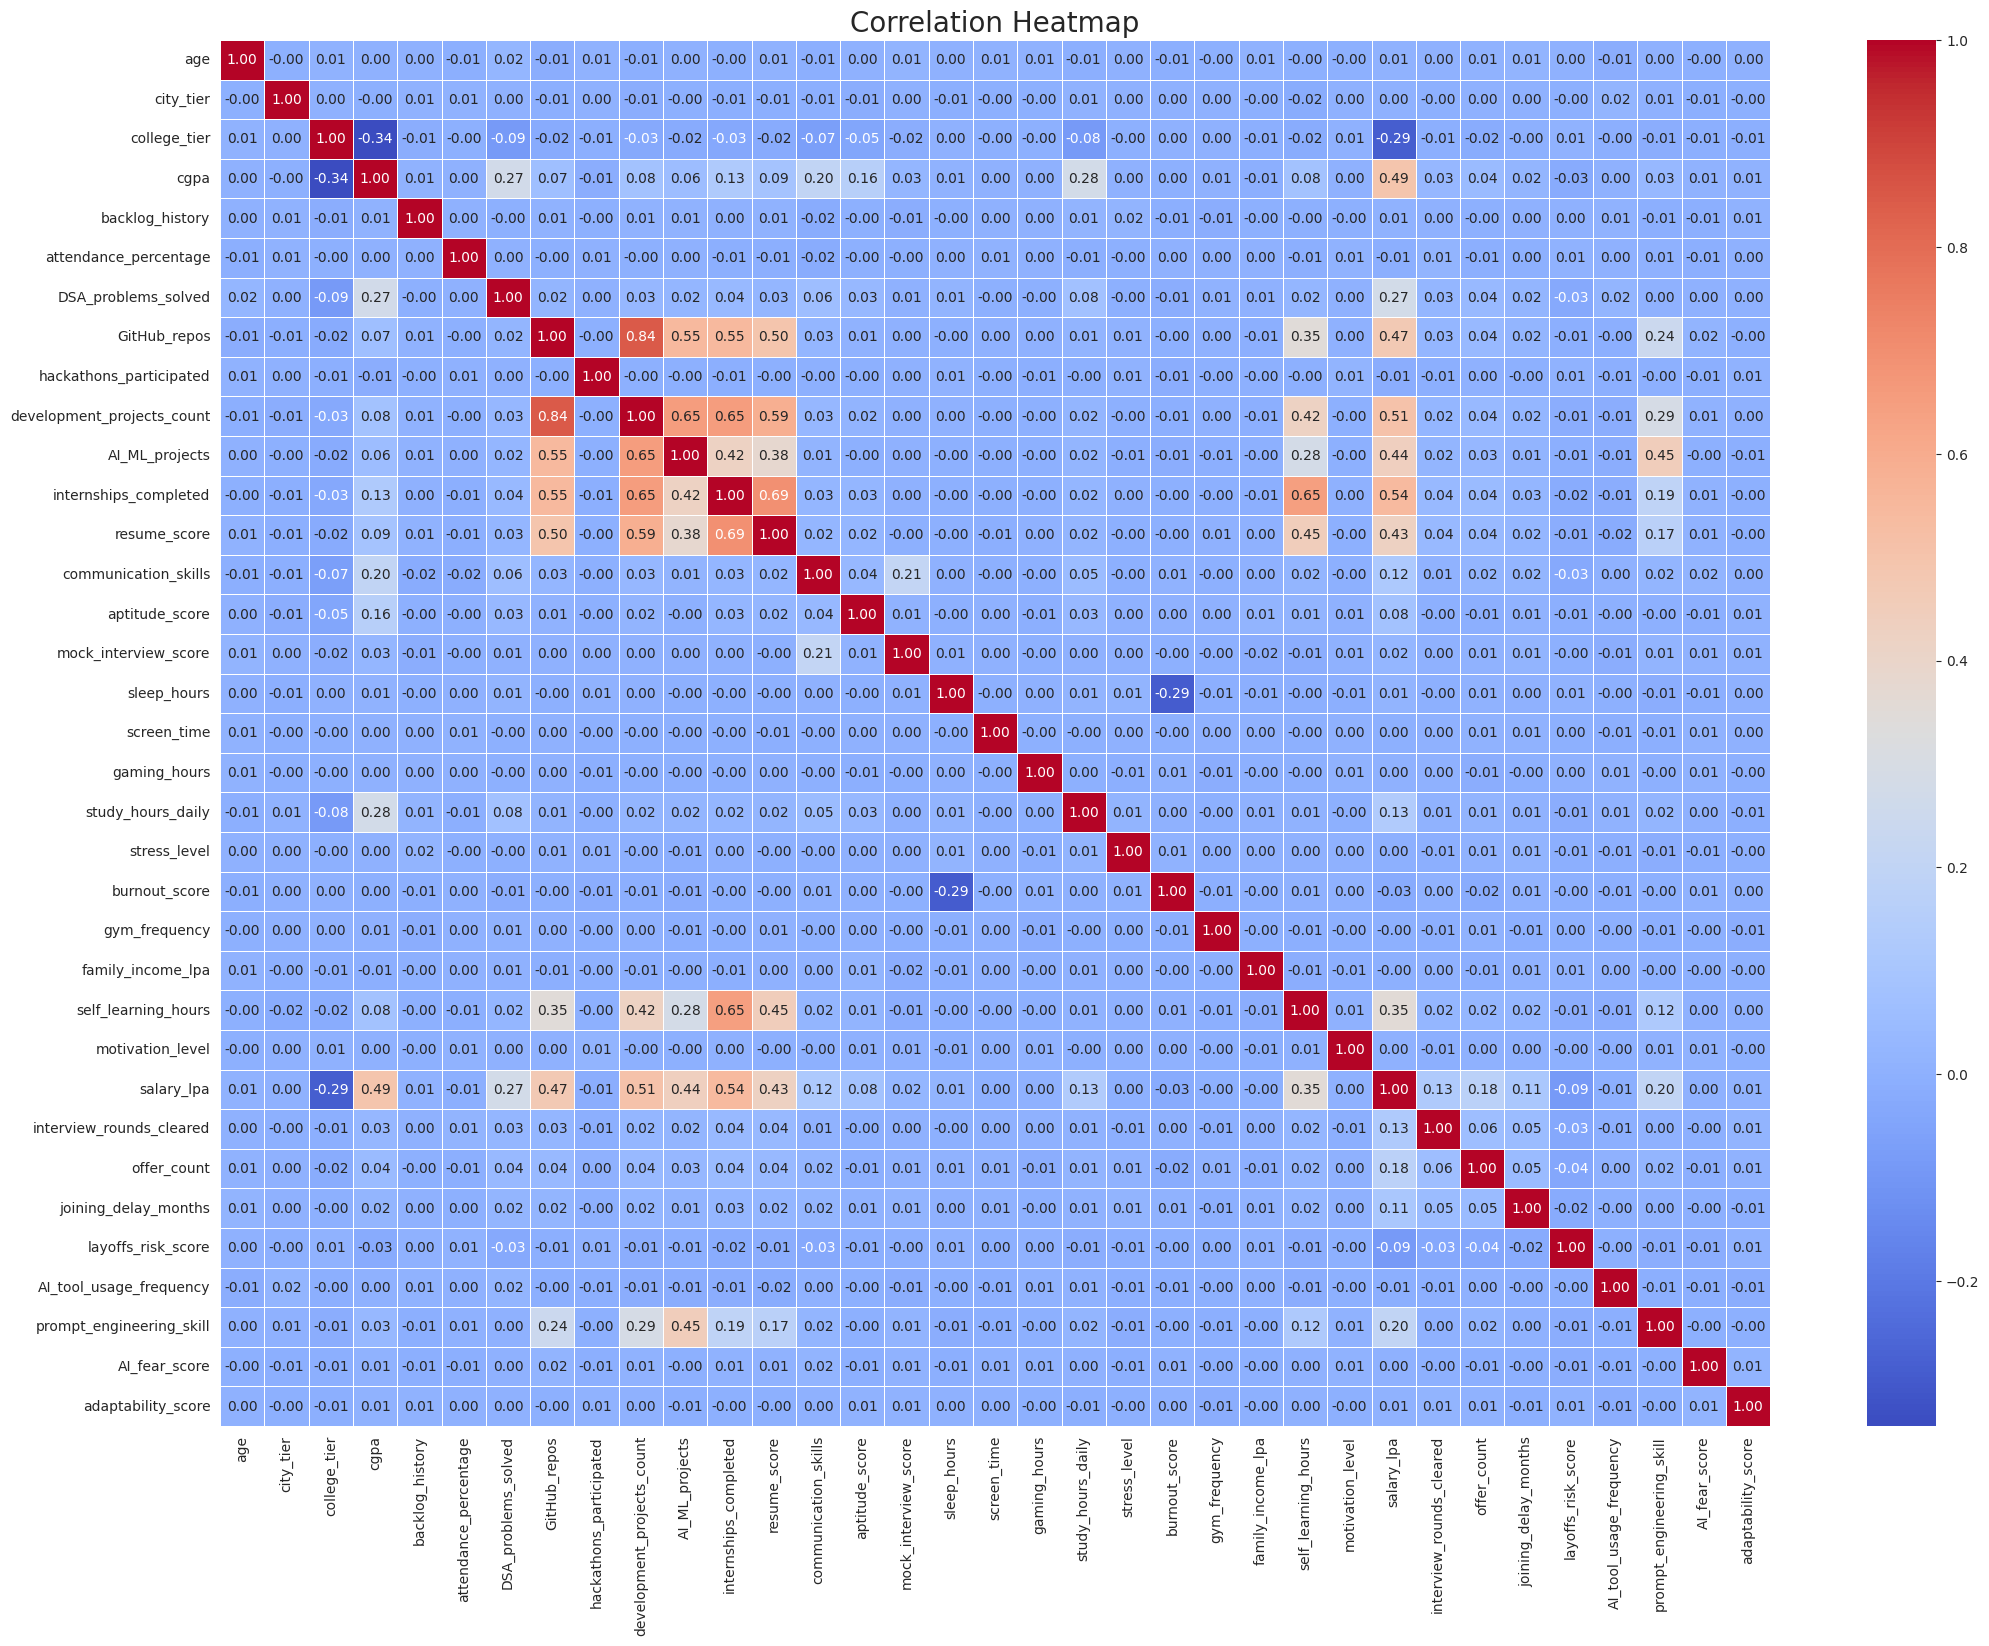

In [35]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(25,18))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=20)
plt.show()

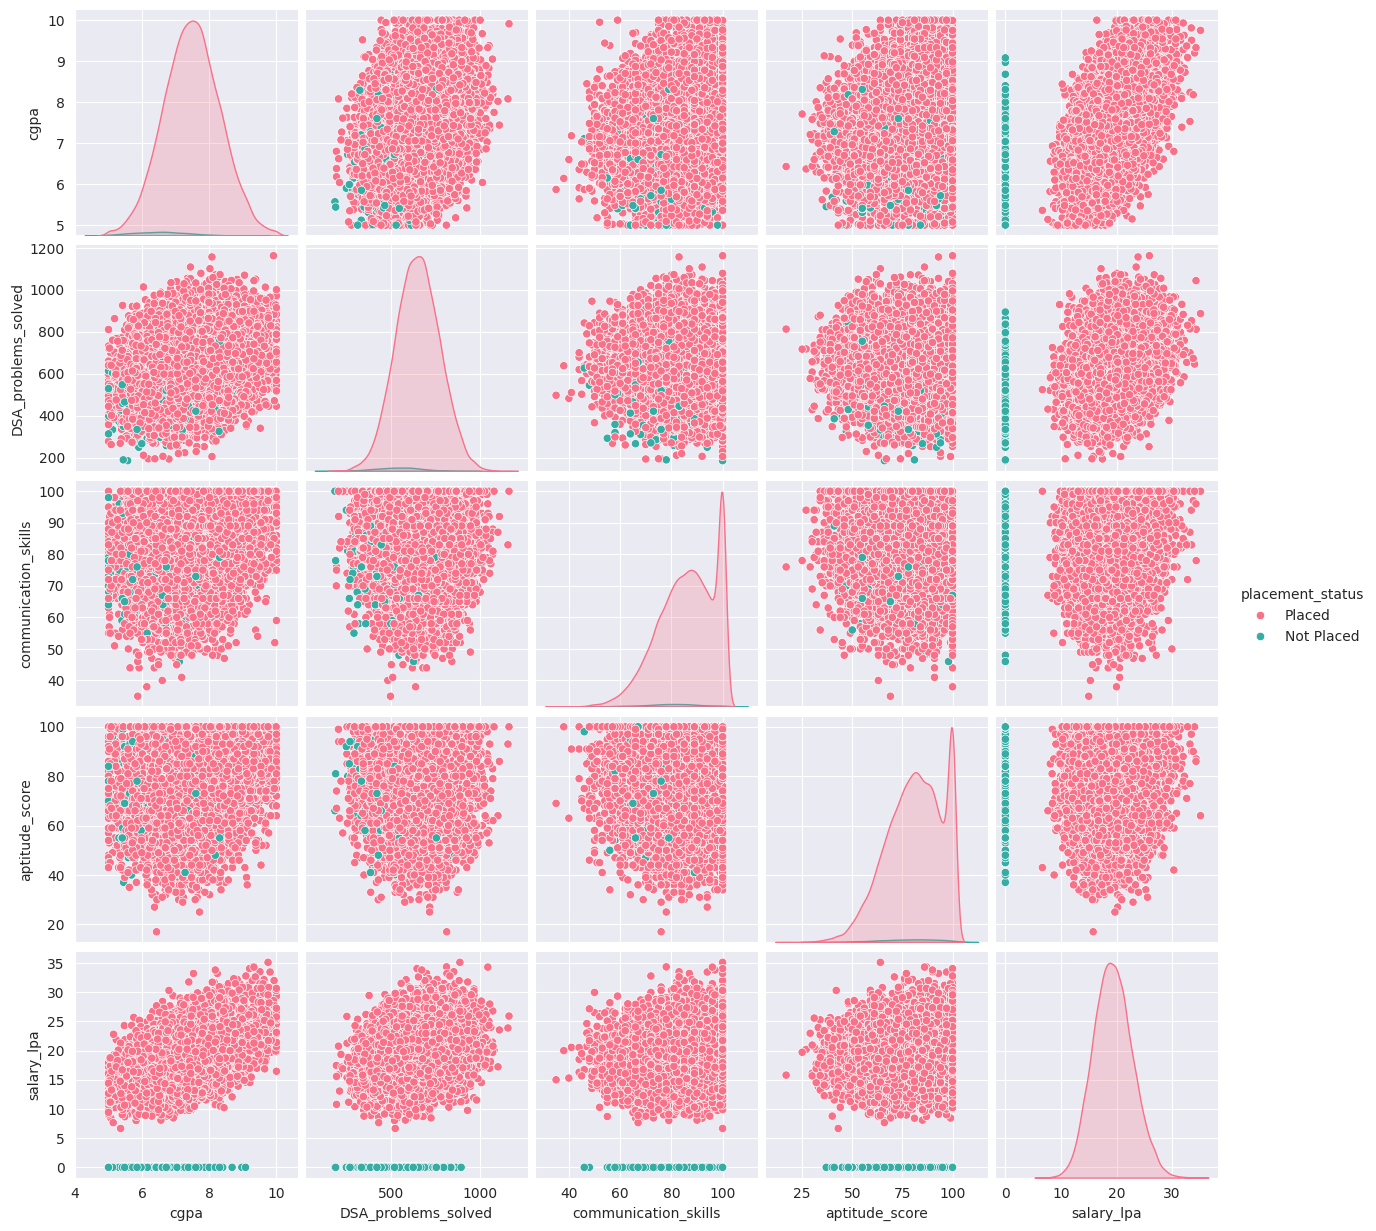

In [36]:
selected_cols = [
    'cgpa',
    'DSA_problems_solved',
    'communication_skills',
    'aptitude_score',
    'salary_lpa',
    'placement_status'
]

sns.pairplot(
    df[selected_cols],
    hue='placement_status',
    palette='husl'
)

plt.show()

In [37]:
fig = px.sunburst(
    df,
    path=['degree', 'branch', 'placement_status'],
    color='salary_lpa',
    color_continuous_scale='RdYlGn',
    title='Degree -> Branch -> Placement'
)

fig.show()

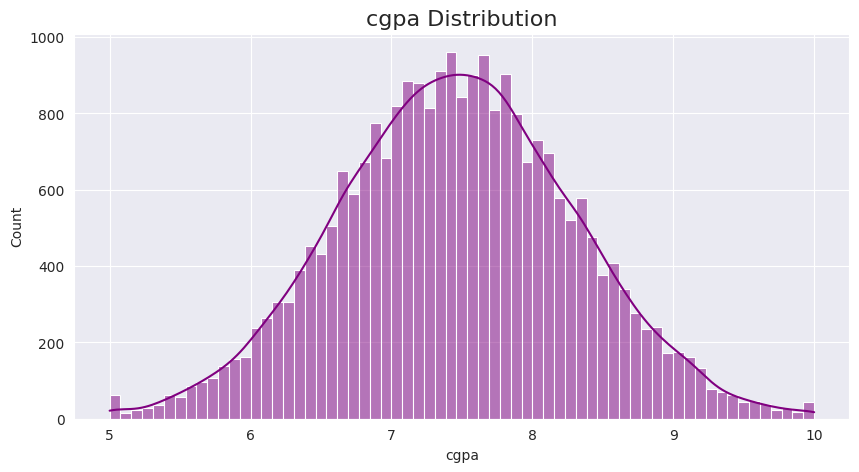

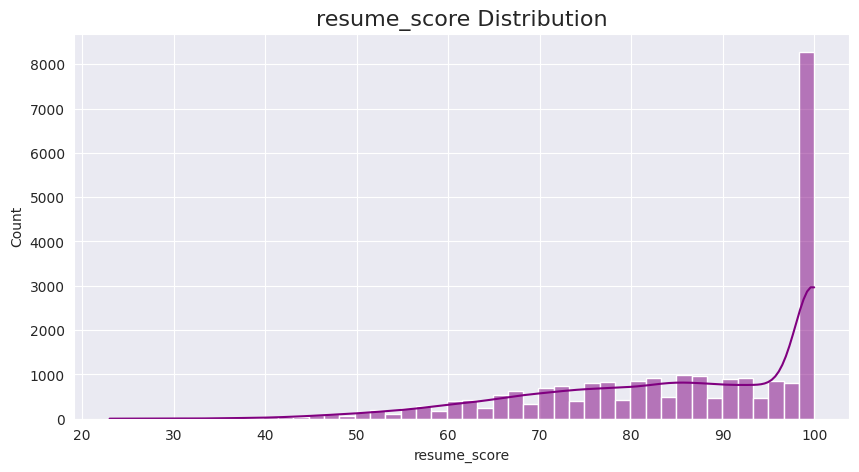

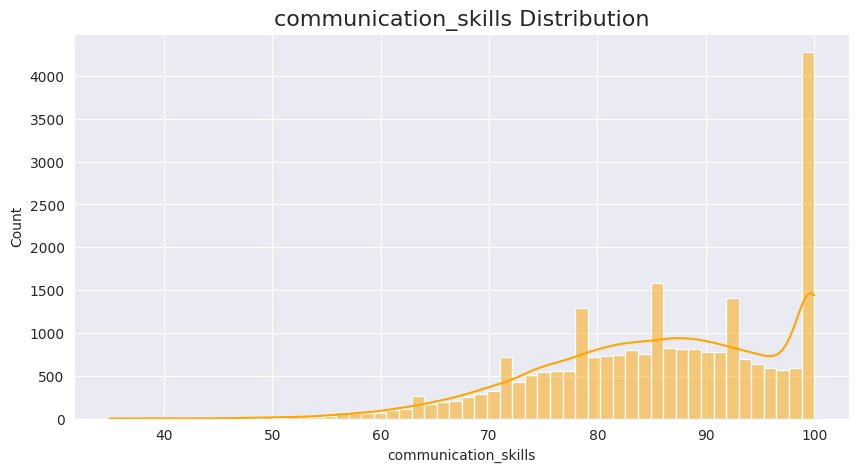

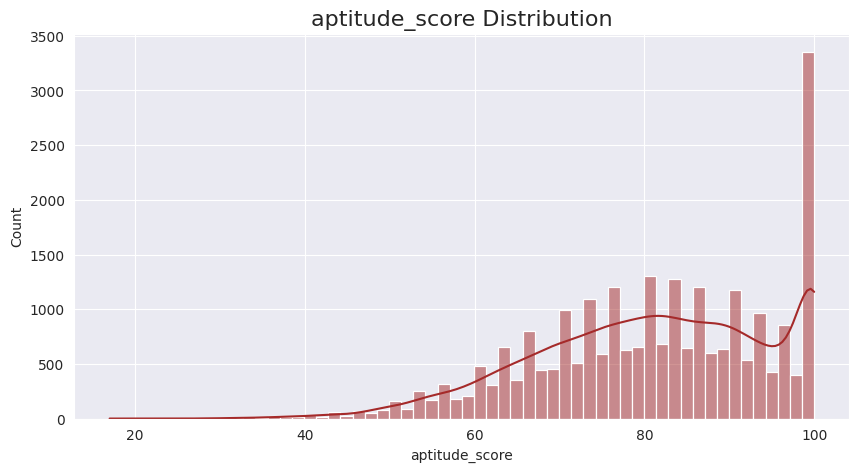

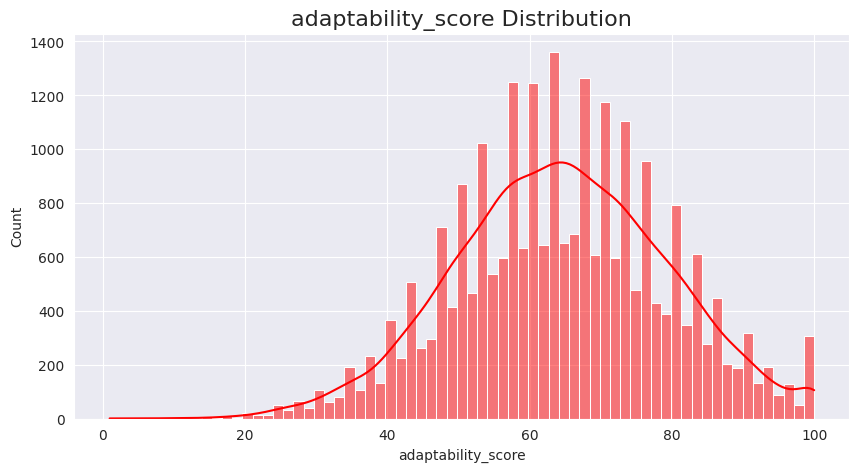

In [38]:
important_features = [
    'cgpa',
    'resume_score',
    'communication_skills',
    'aptitude_score',
    'adaptability_score'
]

for col in important_features:

    plt.figure(figsize=(10,5))

    sns.histplot(
        df[col],
        kde=True,
        color=np.random.choice([
            'red','blue','green','purple','orange','brown'
        ])
    )

    plt.title(f"{col} Distribution", fontsize=16)
    plt.show()


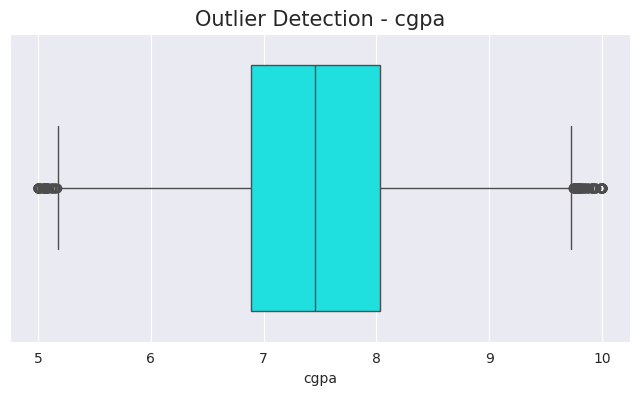

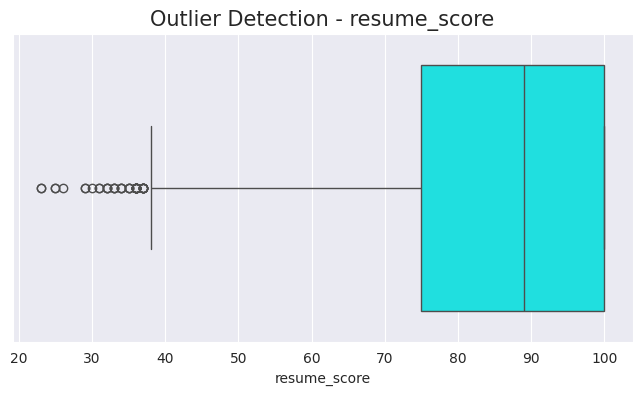

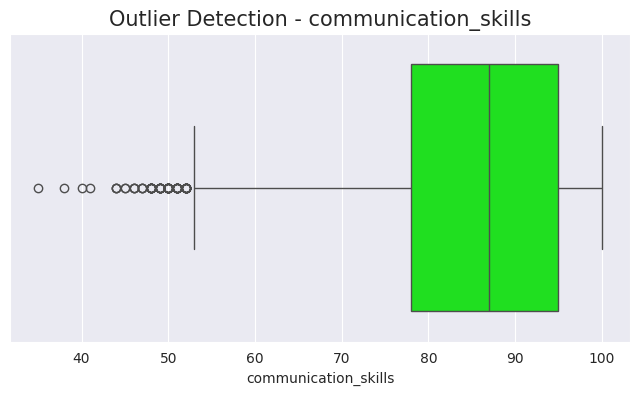

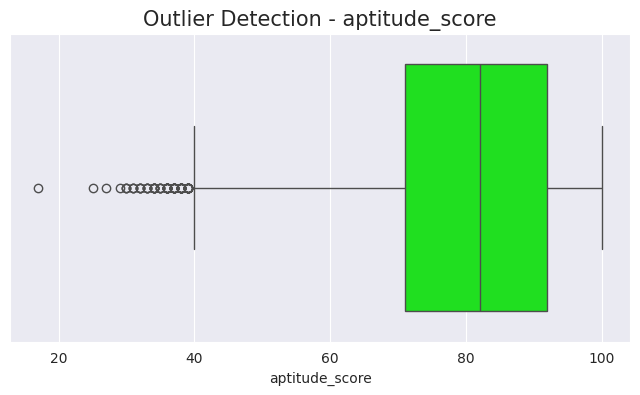

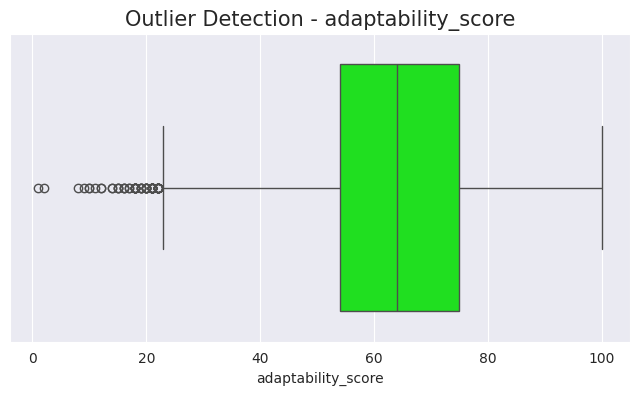

In [39]:
for col in important_features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        x=df[col],
        color=np.random.choice([
            'cyan','magenta','yellow','lime','pink'
        ])
    )

    plt.title(f"Outlier Detection - {col}", fontsize=15)
    plt.show()


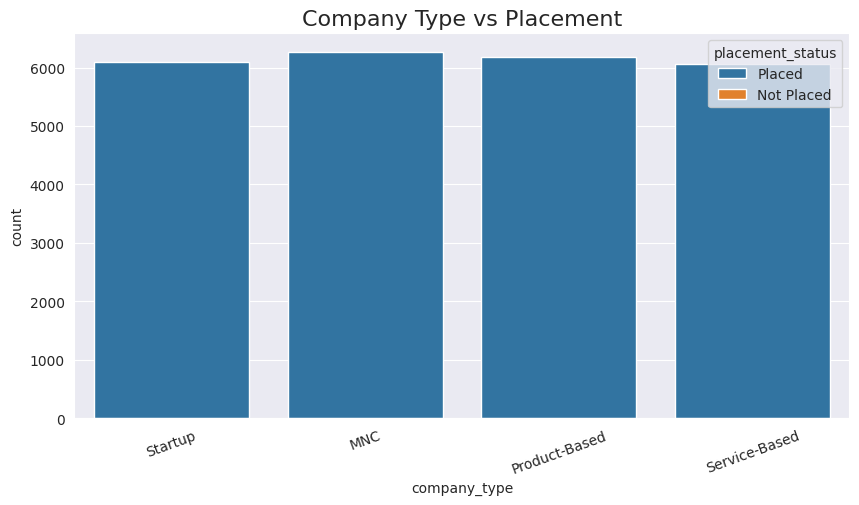

In [40]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='company_type',
    hue='placement_status',
    data=df,
    palette='tab10'
)

plt.title("Company Type vs Placement", fontsize=16)
plt.xticks(rotation=20)
plt.show()

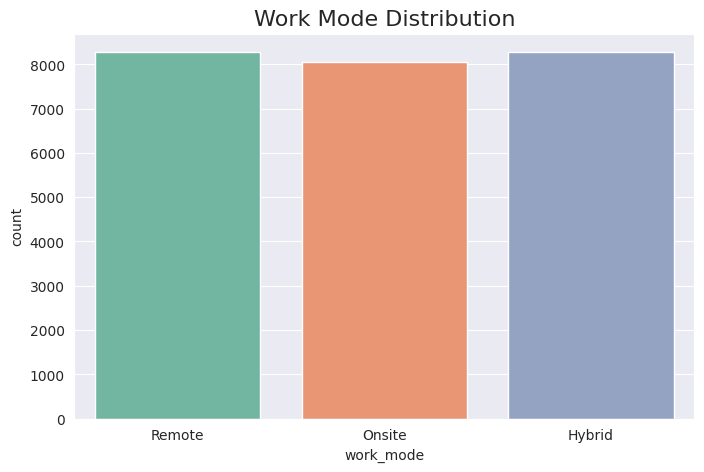

In [41]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='work_mode',
    data=df,
    palette='Set2'
)

plt.title("Work Mode Distribution", fontsize=16)
plt.show()

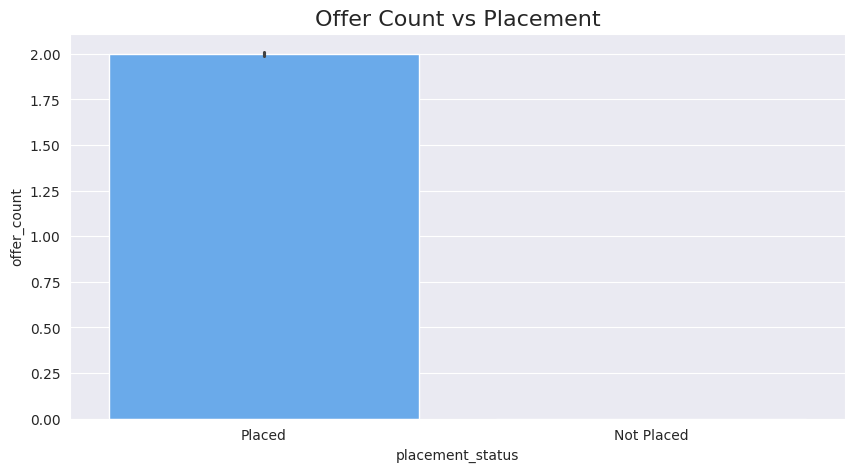

In [42]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='placement_status',
    y='offer_count',
    data=df,
    palette='cool'
)

plt.title("Offer Count vs Placement", fontsize=16)
plt.show()

In [43]:
print("\nVisualization Completed Successfully!")
print("Total Columns Visualized:", len(df.columns))


Visualization Completed Successfully!
Total Columns Visualized: 44


## Feature engineering


Encoded Target Distribution:
placement_status
1    24596
0      404
Name: count, dtype: int64

Training Shape: (20000, 42)
Testing Shape : (5000, 42)

Numerical Features:
Index(['age', 'city_tier', 'college_tier', 'cgpa', 'backlog_history',
       'attendance_percentage', 'DSA_problems_solved', 'GitHub_repos',
       'hackathons_participated', 'development_projects_count',
       'AI_ML_projects', 'internships_completed', 'resume_score',
       'communication_skills', 'aptitude_score', 'mock_interview_score',
       'sleep_hours', 'screen_time', 'gaming_hours', 'study_hours_daily',
       'stress_level', 'burnout_score', 'gym_frequency', 'family_income_lpa',
       'self_learning_hours', 'motivation_level', 'salary_lpa',
       'interview_rounds_cleared', 'offer_count', 'joining_delay_months',
       'layoffs_risk_score', 'AI_tool_usage_frequency',
       'prompt_engineering_skill', 'AI_fear_score', 'adaptability_score'],
      dtype='object')

Categorical Features:
Index(['gender', '

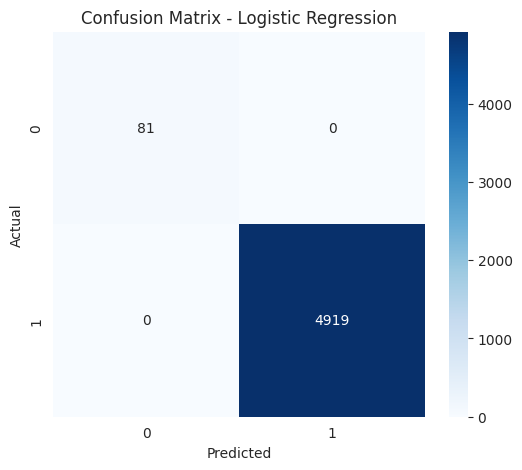

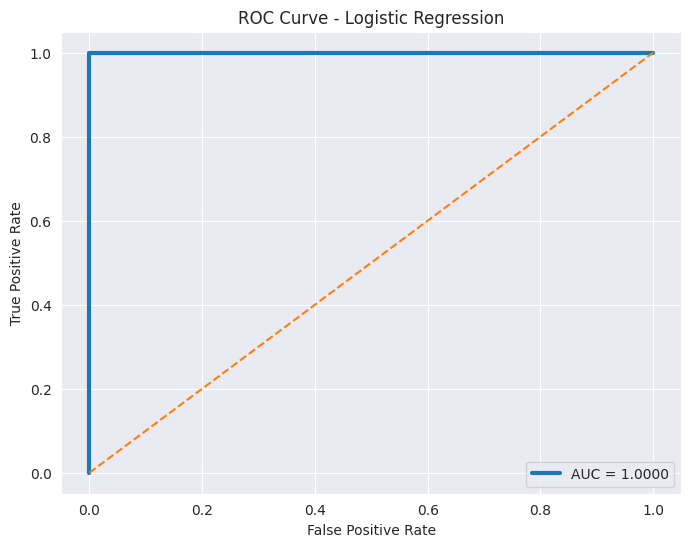



MODEL: Decision Tree

Accuracy Score : 1.0000
Precision Score: 1.0000
Recall Score   : 1.0000
F1 Score       : 1.0000
ROC AUC Score  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00      4919

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



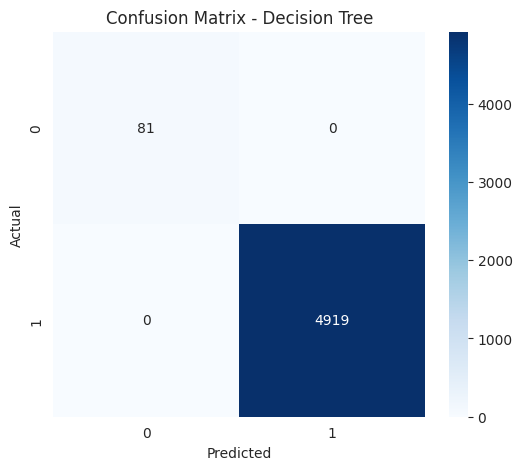

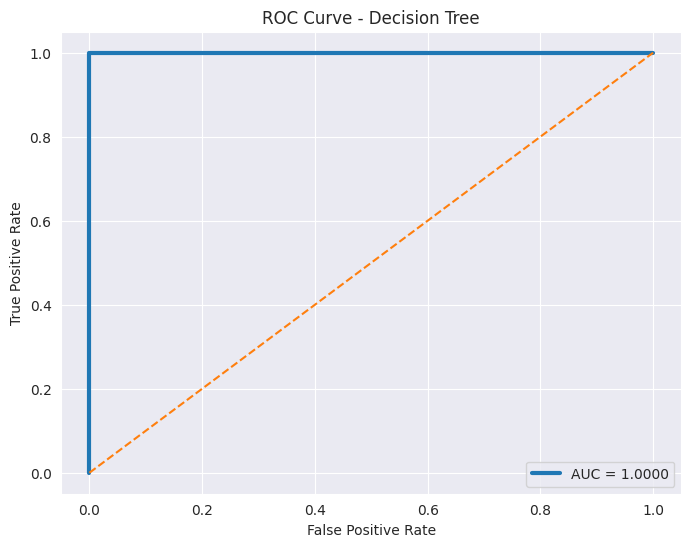



MODEL: Random Forest

Accuracy Score : 1.0000
Precision Score: 1.0000
Recall Score   : 1.0000
F1 Score       : 1.0000
ROC AUC Score  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00      4919

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



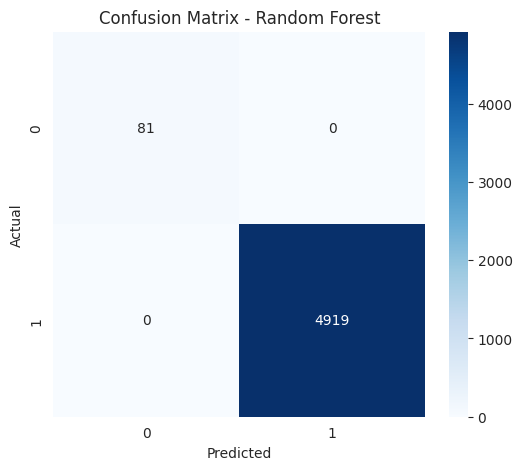

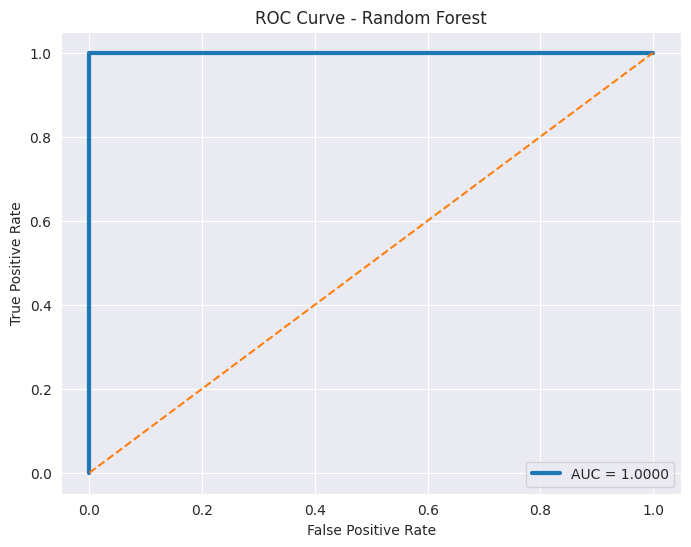



MODEL: Gradient Boosting

Accuracy Score : 1.0000
Precision Score: 1.0000
Recall Score   : 1.0000
F1 Score       : 1.0000
ROC AUC Score  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00      4919

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



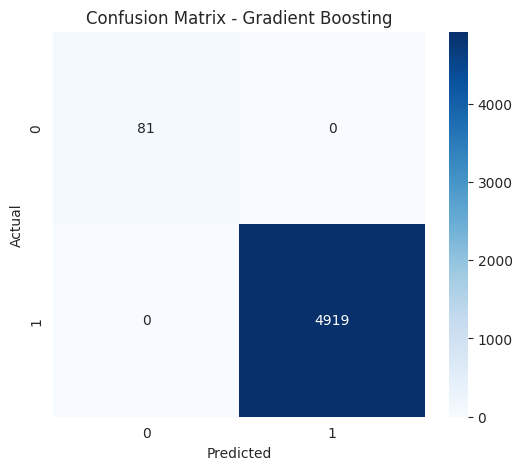

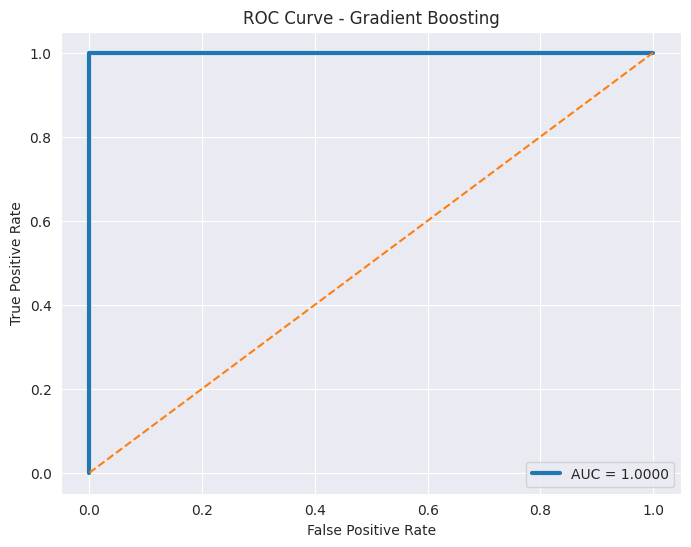



MODEL: AdaBoost

Accuracy Score : 1.0000
Precision Score: 1.0000
Recall Score   : 1.0000
F1 Score       : 1.0000
ROC AUC Score  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00      4919

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



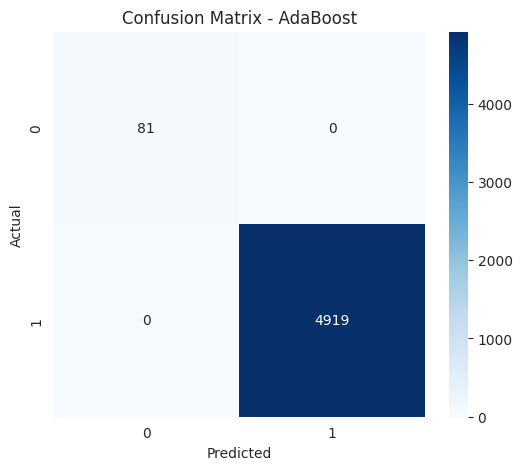

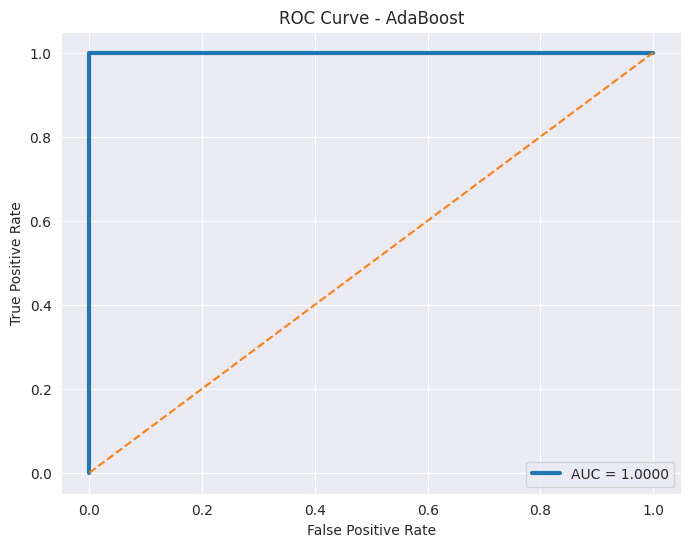



MODEL: KNN

Accuracy Score : 1.0000
Precision Score: 1.0000
Recall Score   : 1.0000
F1 Score       : 1.0000
ROC AUC Score  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00      4919

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



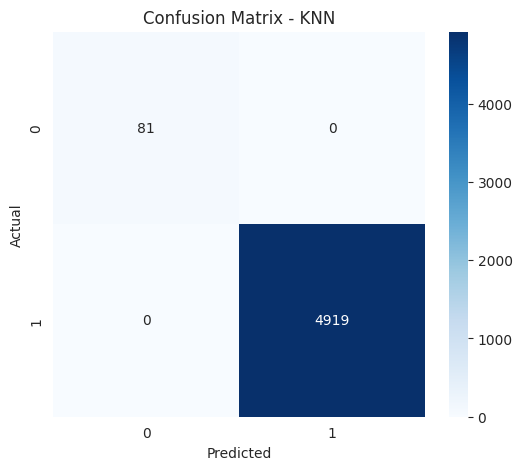

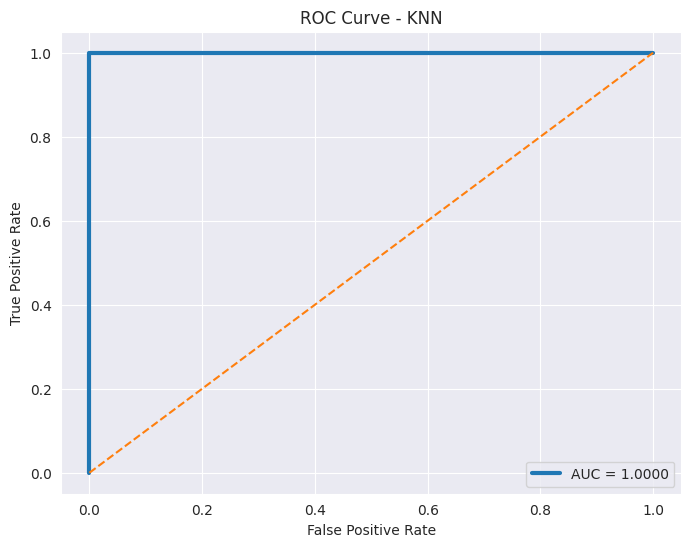



MODEL: SVM

Accuracy Score : 1.0000
Precision Score: 1.0000
Recall Score   : 1.0000
F1 Score       : 1.0000
ROC AUC Score  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00      4919

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



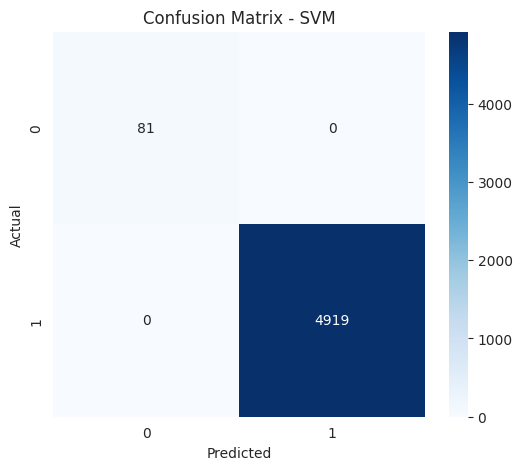

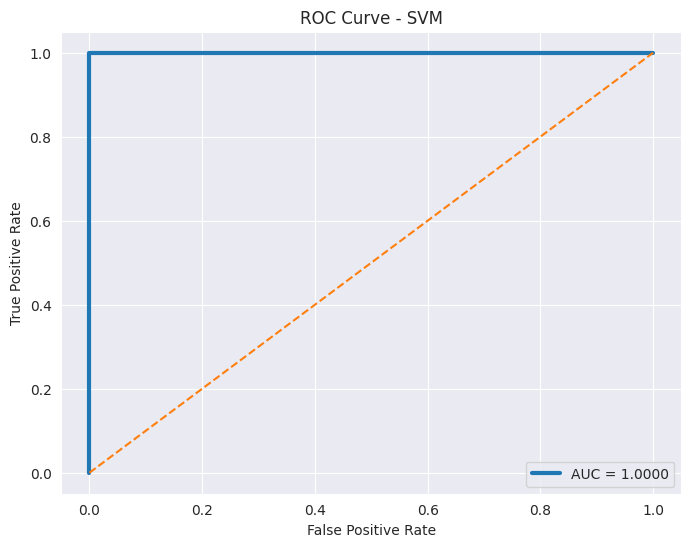



MODEL: XGBoost

Accuracy Score : 1.0000
Precision Score: 1.0000
Recall Score   : 1.0000
F1 Score       : 1.0000
ROC AUC Score  : 1.0000

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        81
           1       1.00      1.00      1.00      4919

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



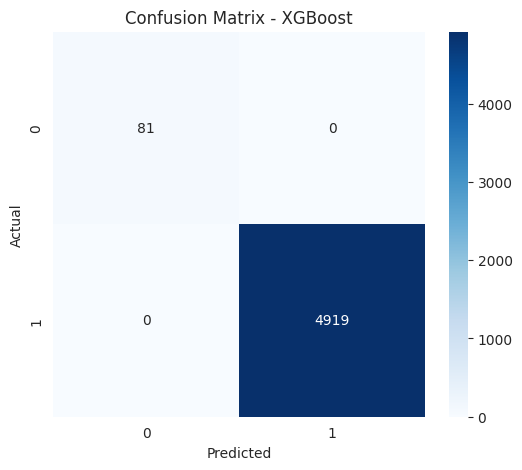

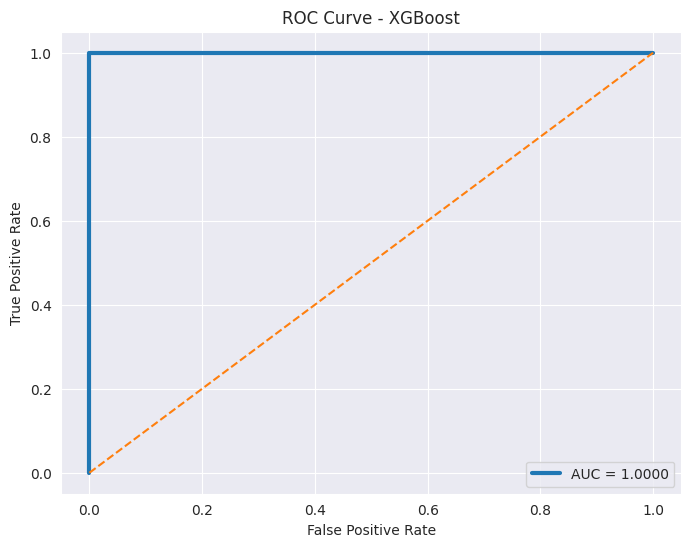



FINAL MODEL COMPARISON
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression       1.0        1.0     1.0       1.0      1.0
1        Decision Tree       1.0        1.0     1.0       1.0      1.0
2        Random Forest       1.0        1.0     1.0       1.0      1.0
3    Gradient Boosting       1.0        1.0     1.0       1.0      1.0
4             AdaBoost       1.0        1.0     1.0       1.0      1.0
5                  KNN       1.0        1.0     1.0       1.0      1.0
6                  SVM       1.0        1.0     1.0       1.0      1.0
7              XGBoost       1.0        1.0     1.0       1.0      1.0


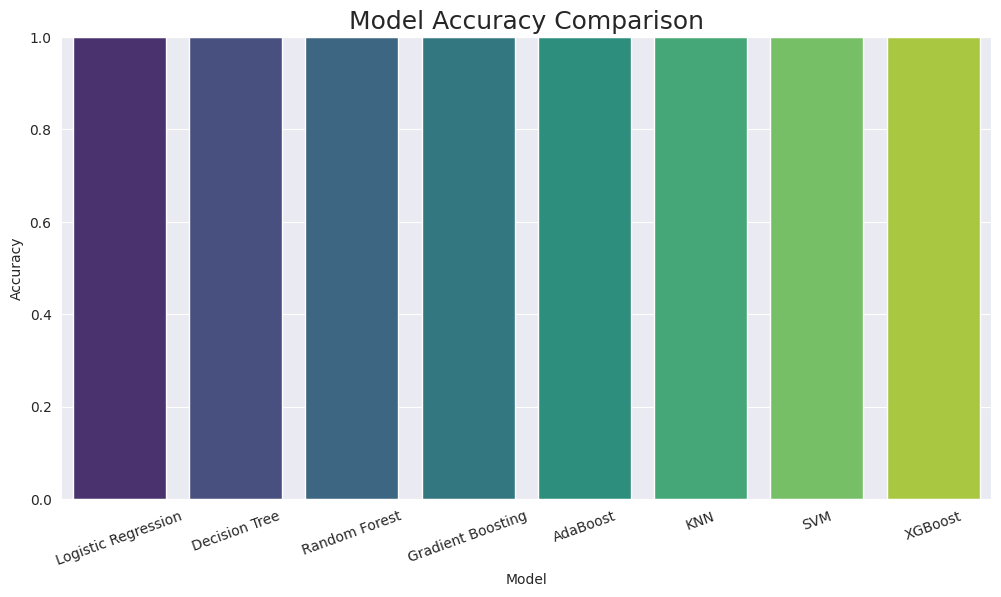

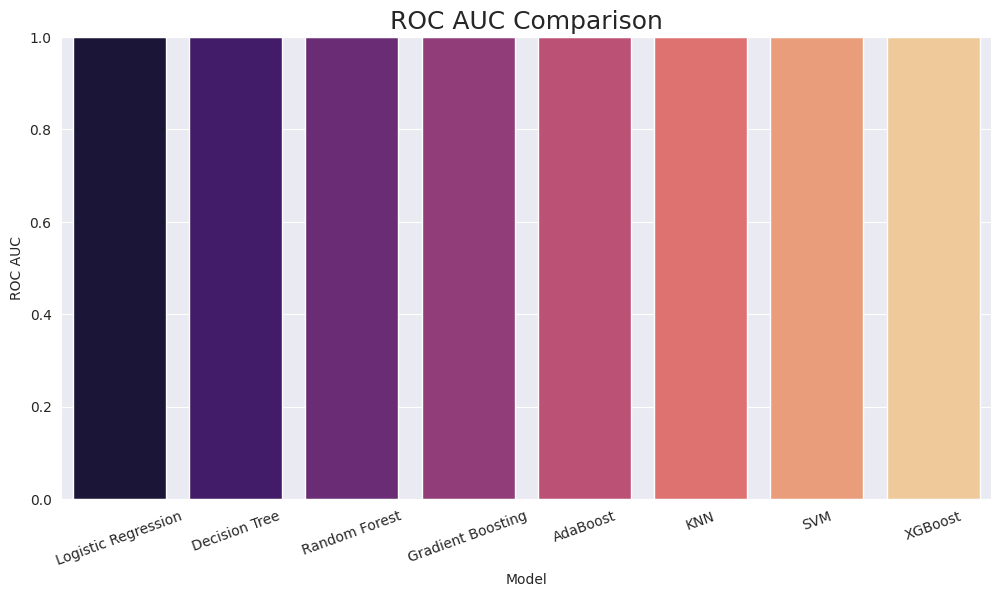



BEST MODEL
Best Model : Logistic Regression
Accuracy   : 1.0000
ROC AUC    : 1.0000


FEATURE IMPORTANCE
                       Feature  Importance
28                 offer_count    0.363226
26                  salary_lpa    0.342028
27    interview_rounds_cleared    0.121548
29        joining_delay_months    0.039438
61            company_type_MNC    0.022654
67            work_mode_Remote    0.017531
30          layoffs_risk_score    0.015353
3                         cgpa    0.013594
6          DSA_problems_solved    0.007049
11       internships_completed    0.006769
7                 GitHub_repos    0.004192
65            work_mode_Hybrid    0.004159
12                resume_score    0.004074
66            work_mode_Onsite    0.003954
24         self_learning_hours    0.003121
9   development_projects_count    0.002456
21               burnout_score    0.002419
13        communication_skills    0.002152
62  company_type_Product-Based    0.001427
10              AI_ML_projects   

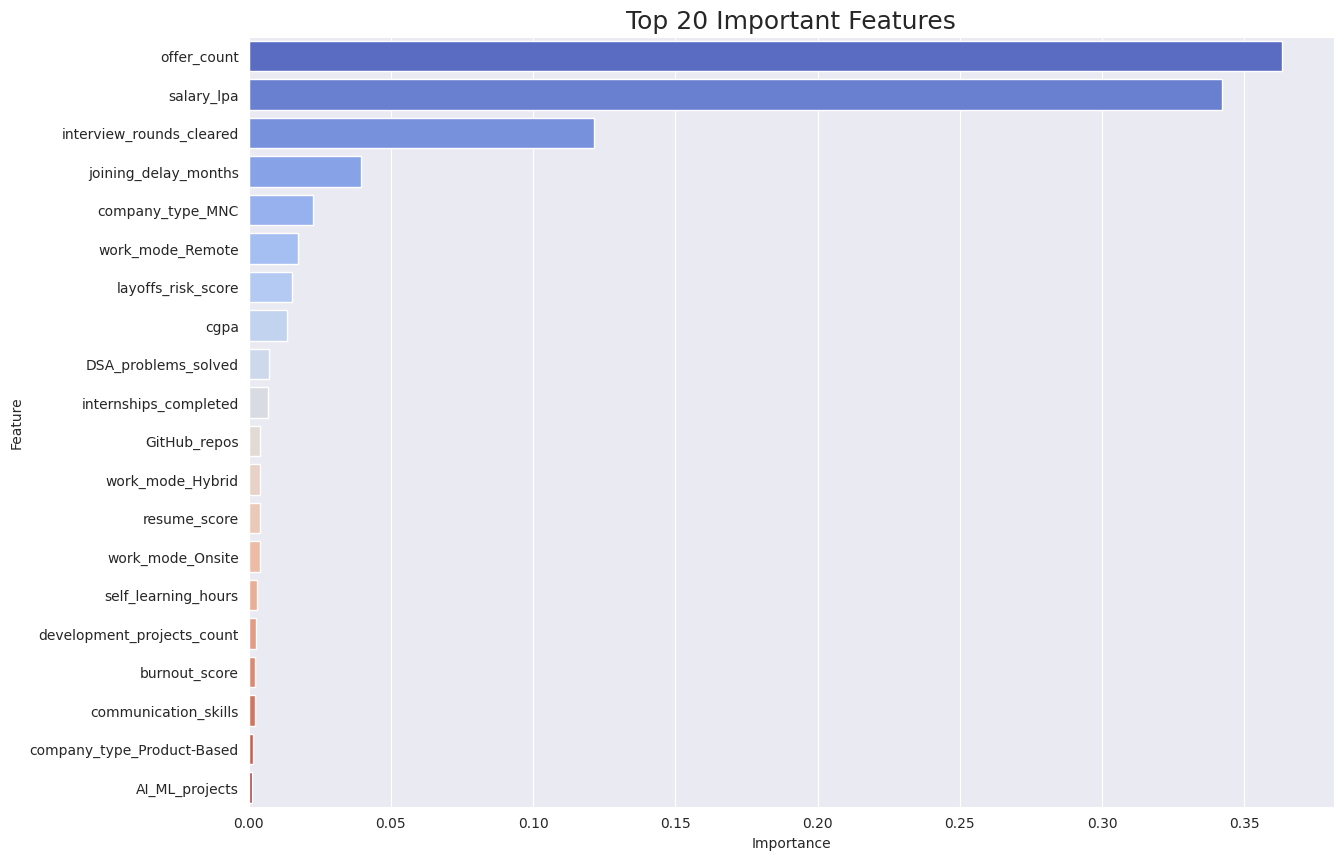



FILES SAVED SUCCESSFULLY
1. model_results.csv
2. feature_importance.csv

Machine Learning Pipeline Completed Successfully!


In [44]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier




# =========================================================
# DROP ID COLUMN
# ========================================================
if 'student_id' in df.columns:
    df.drop('student_id', axis=1, inplace=True)

# =========================================================
# TARGET COLUMN
# =========================================================
target_column = 'placement_status'

# =========================================================
# FEATURES & TARGET
# =========================================================
X = df.drop(target_column, axis=1)

# =========================================================
# TARGET ENCODING
# =========================================================
# Placed = 1
# Not Placed = 0

y = df[target_column].map({

    'Placed': 1,
    'Not Placed': 0

})

print("\nEncoded Target Distribution:")
print(y.value_counts())

# =========================================================
# TRAIN TEST SPLIT
# IMPORTANT:
# SPLIT BEFORE PREPROCESSING
# TO AVOID DATA LEAKAGE
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

# =========================================================
# NUMERICAL & CATEGORICAL COLUMNS
# =========================================================
numeric_features = X.select_dtypes(

    include=['int64', 'float64']

).columns

categorical_features = X.select_dtypes(

    include=['object']

).columns

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

# =========================================================
# NUMERICAL PIPELINE
# =========================================================
numeric_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# =========================================================
# CATEGORICAL PIPELINE
# =========================================================
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('encoder', OneHotEncoder(handle_unknown='ignore'))

])

# =========================================================
# COLUMN TRANSFORMER
# =========================================================
preprocessor = ColumnTransformer(

    transformers=[

        ('num', numeric_transformer, numeric_features),

        ('cat', categorical_transformer, categorical_features)

    ]

)

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(),

    "AdaBoost": AdaBoostClassifier(),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "SVM": SVC(
        probability=True
    ),

    "XGBoost": XGBClassifier(

        eval_metric='logloss',

        random_state=42

    )

}

# =========================================================
# STORE RESULTS
# =========================================================
results = []

# =========================================================
# TRAIN & EVALUATE EACH MODEL
# =========================================================
for model_name, model in models.items():

    print("\n")
    print("="*80)
    print(f"MODEL: {model_name}")
    print("="*80)

    # =====================================================
    # CREATE PIPELINE
    # =====================================================
    pipeline = Pipeline(steps=[

        ('preprocessor', preprocessor),

        ('model', model)

    ])

    # =====================================================
    # TRAIN MODEL
    # =====================================================
    pipeline.fit(X_train, y_train)

    # =====================================================
    # PREDICTIONS
    # =====================================================
    y_pred = pipeline.predict(X_test)

    # =====================================================
    # PROBABILITY PREDICTIONS
    # =====================================================
    if hasattr(pipeline, "predict_proba"):

        y_prob = pipeline.predict_proba(X_test)[:,1]

    else:

        y_prob = pipeline.decision_function(X_test)

    # =====================================================
    # EVALUATION METRICS
    # =====================================================
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    # =====================================================
    # PRINT METRICS
    # =====================================================
    print(f"\nAccuracy Score : {accuracy:.4f}")

    print(f"Precision Score: {precision:.4f}")

    print(f"Recall Score   : {recall:.4f}")

    print(f"F1 Score       : {f1:.4f}")

    print(f"ROC AUC Score  : {roc_auc:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================
    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(

        cm,

        annot=True,

        fmt='d',

        cmap='Blues'

    )

    plt.title(f'Confusion Matrix - {model_name}')

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

    # =====================================================
    # ROC CURVE
    # =====================================================
    fpr, tpr, thresholds = roc_curve(

        y_test,

        y_prob

    )

    plt.figure(figsize=(8,6))

    plt.plot(

        fpr,

        tpr,

        linewidth=3,

        label=f"AUC = {roc_auc:.4f}"

    )

    plt.plot(

        [0,1],

        [0,1],

        linestyle='--'

    )

    plt.xlabel("False Positive Rate")

    plt.ylabel("True Positive Rate")

    plt.title(f"ROC Curve - {model_name}")

    plt.legend()

    plt.show()

    # =====================================================
    # STORE RESULTS
    # =====================================================
    results.append({

        'Model': model_name,

        'Accuracy': accuracy,

        'Precision': precision,

        'Recall': recall,

        'F1 Score': f1,

        'ROC AUC': roc_auc

    })

# =========================================================
# RESULTS DATAFRAME
# =========================================================
results_df = pd.DataFrame(results)

# =========================================================
# SORT RESULTS
# =========================================================
results_df = results_df.sort_values(

    by='Accuracy',

    ascending=False

)

# =========================================================
# SHOW RESULTS
# =========================================================
print("\n")
print("="*80)
print("FINAL MODEL COMPARISON")
print("="*80)

print(results_df)

# =========================================================
# MODEL ACCURACY COMPARISON
# =========================================================
plt.figure(figsize=(12,6))

sns.barplot(

    x='Model',

    y='Accuracy',

    data=results_df,

    palette='viridis'

)

plt.title("Model Accuracy Comparison", fontsize=18)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# =========================================================
# ROC AUC COMPARISON
# =========================================================
plt.figure(figsize=(12,6))

sns.barplot(

    x='Model',

    y='ROC AUC',

    data=results_df,

    palette='magma'

)

plt.title("ROC AUC Comparison", fontsize=18)

plt.xticks(rotation=20)

plt.ylim(0,1)

plt.show()

# =========================================================
# BEST MODEL
# =========================================================
best_model = results_df.iloc[0]

print("\n")
print("="*70)
print("BEST MODEL")
print("="*70)

print(f"Best Model : {best_model['Model']}")

print(f"Accuracy   : {best_model['Accuracy']:.4f}")

print(f"ROC AUC    : {best_model['ROC AUC']:.4f}")

# =========================================================
# FEATURE IMPORTANCE
# USING RANDOM FOREST
# =========================================================
print("\n")
print("="*70)
print("FEATURE IMPORTANCE")
print("="*70)

# =========================================================
# RANDOM FOREST PIPELINE
# =========================================================
rf_pipeline = Pipeline(steps=[

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(

        n_estimators=200,

        random_state=42

    ))

])

# =========================================================
# TRAIN
# =========================================================
rf_pipeline.fit(X_train, y_train)

# =========================================================
# GET FEATURE NAMES
# =========================================================
encoded_cat_features = rf_pipeline.named_steps[
    'preprocessor'
].named_transformers_['cat'][
    'encoder'
].get_feature_names_out(categorical_features)

all_features = np.concatenate([

    numeric_features,

    encoded_cat_features

])

# =========================================================
# IMPORTANCE VALUES
# =========================================================
importances = rf_pipeline.named_steps[
    'model'
].feature_importances_

# =========================================================
# FEATURE IMPORTANCE DATAFRAME
# =========================================================
feature_importance_df = pd.DataFrame({

    'Feature': all_features,

    'Importance': importances

})

feature_importance_df = feature_importance_df.sort_values(

    by='Importance',

    ascending=False

)

# =========================================================
# TOP 20 FEATURES
# =========================================================
top_features = feature_importance_df.head(20)

print(top_features)

# =========================================================
# PLOT FEATURE IMPORTANCE
# =========================================================
plt.figure(figsize=(14,10))

sns.barplot(

    x='Importance',

    y='Feature',

    data=top_features,

    palette='coolwarm'

)

plt.title("Top 20 Important Features", fontsize=18)

plt.show()

# =========================================================
# SAVE RESULTS
# =========================================================
results_df.to_csv(

    "model_results.csv",

    index=False

)

feature_importance_df.to_csv(

    "feature_importance.csv",

    index=False

)

# =========================================================
# SUCCESS MESSAGE
# =========================================================
print("\n")
print("="*70)
print("FILES SAVED SUCCESSFULLY")
print("="*70)

print("1. model_results.csv")

print("2. feature_importance.csv")

print("\nMachine Learning Pipeline Completed Successfully!")

## Thank you...pls upvote!!!!!!!!!!!!!